https://github.com/recommenders-team/recommenders/blob/main/examples/02_model_collaborative_filtering/surprise_svd_deep_dive.ipynb

https://github.com/anthonycreates2000/Travelling-Place-Recommendation-System/blob/main/artificial-intelligence/recommendation_colab_filtering_tourism_analysis_and_svdpp.ipynb

## Import

In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 24.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2469533 sha256=8dda4c129364124497be8e3a22ed7e90a073bc3992325d55e4278931b6054bb8
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from surprise import Dataset, Reader, accuracy, SVD
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# load data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path_final_processed_data = '/content/drive/MyDrive/final_processed_data.csv'
df = pd.read_csv(path_final_processed_data)
df.drop(columns='Unnamed: 0', inplace=True)

Mounted at /content/drive


In [ ]:
df

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...
...,...,...,...,...,...,...,...,...
28146,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,Tissa789,3.0,Starbucks versi Indonesia\nAnomali tuh menurut...
28147,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,si_zel,4.4,Tempat hang out favorit\nLokasinya yang cukup ...
28148,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,Ilma,5.0,"konsepnya asik!\nBegitu masuk, kalian akan lia..."
28149,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,UrsAndNic,4.0,"Homey Coffee shop\nSuka banget ambiencenya,ter..."


# data preparation

In [4]:
rating_data_df = df[['Username', 'Restaurant Name', 'User Rating']].copy()

user_encoder = LabelEncoder()
resto_encoder = LabelEncoder()

rating_data_df['User ID'] = user_encoder.fit_transform(rating_data_df['Username'])
rating_data_df['Restaurant ID'] = resto_encoder.fit_transform(rating_data_df['Restaurant Name'])

rating_data_df = rating_data_df[['User ID', 'Restaurant ID', 'User Rating']]

In [5]:
reader = Reader(rating_scale=(1, 5))

X_trainval, X_test = train_test_split(rating_data_df, test_size=0.2, random_state=42)
X_train, X_val = train_test_split(X_trainval, test_size=0.125, random_state=42) # val : 0.1 dari train

In [6]:
print(len(X_train)) # 70%
print(len(X_val)) # 10%
print(len(X_test)) # 20%

19705
2815
5631


In [7]:
trainset = Dataset.load_from_df(X_train, reader).build_full_trainset()
testset = list(X_test.itertuples(index=False, name=None))
valset = list(X_val.itertuples(index=False, name=None))

# svd

In [8]:
param_grid = {
    'n_epochs': [10, 15, 20],
    'lr_all': [0.01, 0.001, 0.003],
    'reg_all': [0.09, 0.1, 0.11] # regularization term, Default is 0.02
}

best_rmse = float('inf')
best_mae = float('inf')

best_params_mae = None
best_model_mae = None
best_params_rmse = None
best_model_rmse = None

for reg_all in param_grid['reg_all']:
    for n_epochs in param_grid['n_epochs']:
        for lr_all in param_grid['lr_all']:
            print(f"Training with: reg_all={reg_all}, n_epochs={n_epochs}, lr_all={lr_all}")
            model = SVD(reg_all=reg_all, n_epochs=n_epochs, lr_all=lr_all, verbose=False)
            model.fit(trainset)
            val_preds = model.test(valset)
            rmse = accuracy.rmse(val_preds, verbose=False)
            mae = accuracy.mae(val_preds, verbose=False)
            print(f"Validation RMSE: {rmse:.4f}")
            print(f"Validation MAE: {mae:.4f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_params_rmse = {
                    'reg_all': reg_all,
                    'n_epochs': n_epochs,
                    'lr_all': lr_all
                }
                best_model_rmse = model

            if mae < best_mae:
                best_mae = mae
                best_params_mae = {
                    'reg_all': reg_all,
                    'n_epochs': n_epochs,
                    'lr_all': lr_all
                }
                best_model_mae = model

print("\nBest hyperparameters RMSE:", best_params_rmse)
print(f"Best Validation RMSE: {best_rmse:.4f}")

print("\nBest hyperparameters MAE:", best_params_mae)
print(f"Best Validation MAE: {best_mae:.4f}")

Training with: reg_all=0.09, n_epochs=10, lr_all=0.01
Validation RMSE: 0.4039
Validation MAE: 0.3070
Training with: reg_all=0.09, n_epochs=10, lr_all=0.001
Validation RMSE: 0.4389
Validation MAE: 0.3372
Training with: reg_all=0.09, n_epochs=10, lr_all=0.003
Validation RMSE: 0.4203
Validation MAE: 0.3207
Training with: reg_all=0.09, n_epochs=15, lr_all=0.01
Validation RMSE: 0.4036
Validation MAE: 0.3065
Training with: reg_all=0.09, n_epochs=15, lr_all=0.001
Validation RMSE: 0.4326
Validation MAE: 0.3331
Training with: reg_all=0.09, n_epochs=15, lr_all=0.003
Validation RMSE: 0.4134
Validation MAE: 0.3149
Training with: reg_all=0.09, n_epochs=20, lr_all=0.01
Validation RMSE: 0.3982
Validation MAE: 0.3025
Training with: reg_all=0.09, n_epochs=20, lr_all=0.001
Validation RMSE: 0.4292
Validation MAE: 0.3282
Training with: reg_all=0.09, n_epochs=20, lr_all=0.003
Validation RMSE: 0.4080
Validation MAE: 0.3112
Training with: reg_all=0.1, n_epochs=10, lr_all=0.01
Validation RMSE: 0.4047
Validati

In [9]:
epoch = best_params_rmse['n_epochs'] # best params rmse atau mae sama aja
reg_all = best_params_rmse['reg_all']
lr_all = best_params_rmse['lr_all']

rmse_train, rmse_val = [], []
mae_train, mae_val = [], []

for epoch in range(1, epoch + 1):
    model = SVD(n_epochs=epoch, reg_all=reg_all, lr_all=lr_all, verbose=False)
    model.fit(trainset)

    train_preds = model.test(trainset.build_testset())
    val_preds = model.test(valset)

    # RMSE
    rmse_train.append(accuracy.rmse(train_preds, verbose=False))
    rmse_val.append(accuracy.rmse(val_preds, verbose=False))

    # MAE
    mae_train.append(accuracy.mae(train_preds, verbose=False))
    mae_val.append(accuracy.mae(val_preds, verbose=False))

    print(f"Epoch {epoch}")
    print(f"RMSE - Train: {rmse_train[-1]:.4f}")
    print(f"RMSE - Val  : {rmse_val[-1]:.4f}")
    print(f"MAE  - Train: {mae_train[-1]:.4f}")
    print(f"MAE  - Val  : {mae_val[-1]:.4f}")


Epoch 1
RMSE - Train: 0.4415
RMSE - Val  : 0.4394
MAE  - Train: 0.3411
MAE  - Val  : 0.3379
Epoch 2
RMSE - Train: 0.4156
RMSE - Val  : 0.4276
MAE  - Train: 0.3193
MAE  - Val  : 0.3298
Epoch 3
RMSE - Train: 0.4008
RMSE - Val  : 0.4209
MAE  - Train: 0.3070
MAE  - Val  : 0.3215
Epoch 4
RMSE - Train: 0.3896
RMSE - Val  : 0.4161
MAE  - Train: 0.2983
MAE  - Val  : 0.3170
Epoch 5
RMSE - Train: 0.3813
RMSE - Val  : 0.4137
MAE  - Train: 0.2917
MAE  - Val  : 0.3141
Epoch 6
RMSE - Train: 0.3740
RMSE - Val  : 0.4094
MAE  - Train: 0.2858
MAE  - Val  : 0.3114
Epoch 7
RMSE - Train: 0.3685
RMSE - Val  : 0.4082
MAE  - Train: 0.2818
MAE  - Val  : 0.3115
Epoch 8
RMSE - Train: 0.3629
RMSE - Val  : 0.4078
MAE  - Train: 0.2771
MAE  - Val  : 0.3113
Epoch 9
RMSE - Train: 0.3591
RMSE - Val  : 0.4048
MAE  - Train: 0.2744
MAE  - Val  : 0.3072
Epoch 10
RMSE - Train: 0.3564
RMSE - Val  : 0.4039
MAE  - Train: 0.2722
MAE  - Val  : 0.3074
Epoch 11
RMSE - Train: 0.3525
RMSE - Val  : 0.4039
MAE  - Train: 0.2690
MAE  - 

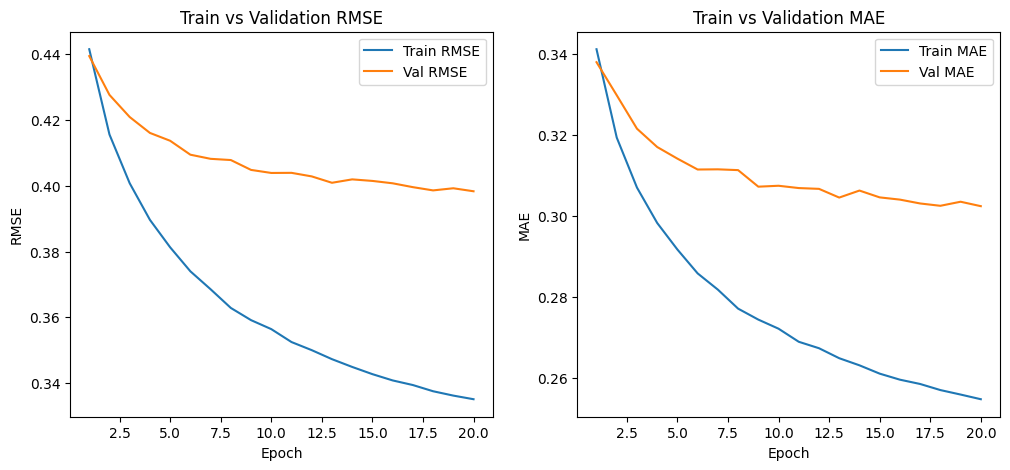

In [10]:
plt.figure(figsize=(12, 5))

# RMSE Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epoch+1), rmse_train, label='Train RMSE')
plt.plot(range(1, epoch+1), rmse_val, label='Val RMSE')
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Train vs Validation RMSE")
plt.legend()

# MAE Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epoch+1), mae_train, label='Train MAE')
plt.plot(range(1, epoch+1), mae_val, label='Val MAE')
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Train vs Validation MAE")
plt.legend()

# plt.tight_layout()
plt.show()

In [11]:
predictions = best_model_rmse.test(testset)

print("Test Set")
test_rmse = accuracy.rmse(predictions)
test_mae = accuracy.mae(predictions)


Test Set
RMSE: 0.4198
MAE:  0.3167


In [12]:
K = 10
threshold = 4.0  # treshold rating

# Group predictions by user
def get_top_k(predictions, k=10):
    top_k = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_k[uid].append((iid, est, true_r))

    # Sort prediksi berdasarkan estimasi rating tertinggi
    for uid, user_ratings in top_k.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_k[uid] = user_ratings[:k]

    return top_k

top_k_preds = get_top_k(predictions, k=K)

precisions = []
recalls = []

relevant_items_per_user = defaultdict(set)
for uid, iid, true_r, est, _ in predictions:
    if true_r >= threshold:
        relevant_items_per_user[uid].add(iid)

for uid, user_ratings in top_k_preds.items():
    recommended_iids = [iid for iid, est, true_r in user_ratings if est >= threshold]
    relevant_iids = relevant_items_per_user[uid]

    n_rel = len(relevant_iids)
    n_rec_k = len(recommended_iids)
    n_rel_and_rec_k = len(set(recommended_iids) & relevant_iids)

    if n_rec_k > 0:
        precisions.append(n_rel_and_rec_k / n_rec_k)
    if n_rel > 0:
        recalls.append(n_rel_and_rec_k / n_rel)

precision_at_k = np.mean(precisions)
recall_at_k = np.mean(recalls)

print('Test Set')
print(f"Precision@{K}: {precision_at_k:.4f}")
print(f"Recall@{K}: {recall_at_k:.4f}")

Test Set
Precision@10: 0.7816
Recall@10: 0.8018


# Recommend

recommend for new user

In [ ]:
def recommend_from_favorite_restos(fav_resto_names, df, resto_encoder, model, k=10):
    # 1. Encode user input
    fav_resto_ids = resto_encoder.transform(fav_resto_names)

    # 2. create new user id (krn new user kan dianggap nya)
    new_user_id = df['User ID'].max() + 1

    # 3. new df
    new_df = pd.DataFrame({
        'User ID': [new_user_id] * len(fav_resto_ids),
        'Restaurant ID': fav_resto_ids,
        'User Rating': [5.0] * len(fav_resto_ids)
    })

    # 4. combine
    temp_df = pd.concat([df, new_df], ignore_index=True)

    # 5. convert to surprise df
    reader = Reader(rating_scale=(1, 5))
    trainset = Dataset.load_from_df(temp_df[['User ID', 'Restaurant ID', 'User Rating']], reader).build_full_trainset()

    # 6. retrain
    temp_model = SVD(n_epochs=20, reg_all=0.11, lr_all=0.01, verbose=False)
    temp_model.fit(trainset)

    # 7. Cari semua restoran yang belum dirating
    all_restaurant_ids = df['Restaurant ID'].unique()
    unrated_restaurant_ids = np.setdiff1d(all_restaurant_ids, fav_resto_ids)

    # 8. Prediksi rating restoran yang belum pernah dirating user
    predictions = [
        (resto_id, temp_model.predict(new_user_id, resto_id).est)
        for resto_id in unrated_restaurant_ids
    ]
    predictions.sort(key=lambda x: x[1], reverse=True)

    # 9. top k
    top_k_predictions = predictions[:k]
    top_k_names = [(resto_encoder.inverse_transform([resto_id])[0], rating)
                   for resto_id, rating in top_k_predictions]

    return top_k_names

search sample

In [ ]:
resto_names = list(resto_encoder.classes_)
print(f"{len(resto_names)} restoran\n")

# search restaurant containing keywords
search_keyword = "sushi"
matches = [name for name in resto_names if search_keyword.lower() in name.lower()]

print(f"Hasil pencarian untuk '{search_keyword}':")
for i, name in enumerate(matches, 1):
    print(f'{i}. {name}')

1046 restoran

Hasil pencarian untuk 'sushi':
1. Genki Sushi
2. Gion The Sushi Bar
3. Kappa Sushi
4. Kinka Sushi Bar Izakaya
5. Kintaro Sushi
6. Kohai Sushi Bar
7. Okinawa Sushi
8. Shori Sushi Bar
9. Sushi Apa
10. Sushi Go!
11. Sushi Hiro
12. Sushi Maru
13. Sushi Masa
14. Sushi Sei
15. Sushi Tei
16. Sushi Tei Cafe
17. Sushi Tengoku
18. Sushi Toku
19. Sushiro
20. Tokio Sushi
21. Tom Sushi


user input & recommend

In [ ]:
# tes user inpout
fav_restos = ['Sushi Maru', 'UKI Matcha'] # 5
# user minimal review brp
recommendations = recommend_from_favorite_restos(fav_restos, rating_data_df, resto_encoder, model, k=10)

print("Rekomendasi restoran untuk kamu yang suka:")
for r in fav_restos:
    print(f"  - {r}")

print("\nTop 10 Rekomendasi:")
for i, (resto, rating) in enumerate(recommendations, 1):
    print(f"{i}. {resto}")

# 57 detik - 1 mnt lebih

Rekomendasi restoran untuk kamu yang suka:
  - Sushi Maru
  - UKI Matcha

Top 10 Rekomendasi:
1. Rambla Coffee
2. Sugar & Spice - Hotel InterContinental Jakarta Pondok Indah
3. Bel Etage - Hotel The St. Regis Jakarta
4. Caspar - The Orient Hotel
5. Altitude Grill
6. Lugua Cafe
7. Jowa
8. Nidcielo
9. Steak 21 Buffet
10. Leisola by Aljazeerah


save model

In [14]:
import pickle

# rubah di streamlit yg terbaru pkl
with open('/content/drive/MyDrive/svd.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model_rmse,
        'rating_data_df': rating_data_df,
        'resto_encoder': resto_encoder,
        'best_params': best_params_rmse
    }, f)

print("saved")

saved
